In [2]:
#import required libraries — we do need the models, flatten, dense, input layers 
import numpy as np 
import pandas as pd
from glob import glob 
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten,SeparableConv2D,GlobalMaxPooling2D,GlobalAveragePooling2D,MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.layers import Conv2D
import gc
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2M
from tensorflow.keras.layers import Conv2D, Conv1D,BatchNormalization,Add, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input,GlobalAveragePooling2D,GlobalMaxPooling2D,Dense,Reshape, MaxPool2D,Multiply
from tensorflow.keras.models import Model

In [3]:
def eca(inputs, ratio=16):
    # Create ECA block
    x=inputs
    x1 = GlobalAveragePooling2D()(x)
    #q = GlobalStdPooling()(x) 
    #x1=p+q
    x1=Reshape((x.shape[-1],1))(x1)
    #x1 = Dense(units=x.shape[-1] // 16, activation='relu')(x1)
    x1=Conv1D(filters=1,kernel_size=3,padding='same',activation='sigmoid')(x1)
    #x1 = Dense(units=x.shape[-1], activation='sigmoid')(x1)
    x1=Reshape((x.shape[-1],))(x1)
    #x1=GroupNormalization(groups=4)(x1)

    x2 = GlobalMaxPooling2D()(x)
    #z = GlobalStdPooling()(x) 
    #x2=y+z 
    x2=Reshape((x.shape[-1],1))(x2)
    x2=Conv1D(filters=1,kernel_size=3,padding='same',activation='sigmoid')(x2)
    #x2 = Dense(units=x.shape[-1] // 16, activation='relu')(x2)
    #x2 = Dense(units=x.shape[-1], activation='relu')(x2)
    x2=Reshape((x.shape[-1],))(x2)
    #x2=GroupNormalization(groups=4)(x2)
    #x2 = GlobalStdPooling()(x)
    #y = GlobalAveragePooling2D()(x)


    #x2=GroupNormalization(groups=4)(x2)

    features=x1
    #features=Activation("sigmoid")(features)

    excitation = Reshape((1, 1, x.shape[-1]))(features)
    scale = Multiply()([x, excitation]) 
    return scale

Found 20000 images belonging to 5 classes.
Found 0 images belonging to 5 classes.
Found 5000 images belonging to 5 classes.
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_6 (Conv2D)              (None, 224, 224, 8)  224         ['input_2[0][0]']                
                                                                                                  
 batch_normalization_9 (BatchNo  (None, 224, 224, 8)  32         ['conv2d_6[0][0]']               
 rmalization)                                                      

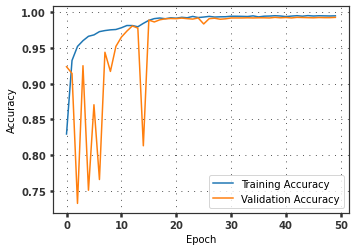

C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:296: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  y_pred = model.predict_generator(test_set,verbose=1)


313/313 [==============================] - 47s 148ms/step


C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])

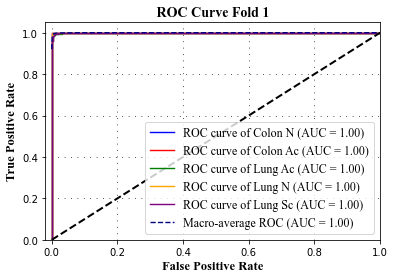

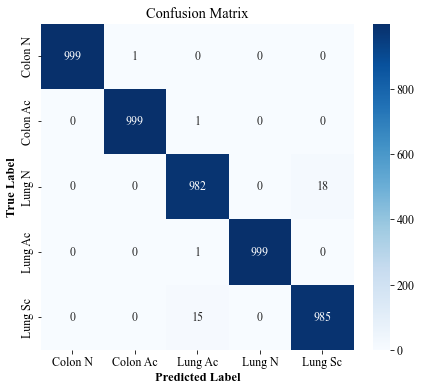

Fold 1
Accuracy: 0.9928
Precision (Macro): 0.9928
Recall (Macro): 0.9928
F1 Score (Macro): 0.9928
Kappa Score : 0.9910
AUC : 0.9998
Found 20000 images belonging to 5 classes.
Found 0 images belonging to 5 classes.
Found 5000 images belonging to 5 classes.
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_12 (Conv2D)             (None, 224, 224, 8)  224         ['input_3[0][0]']                
                                                                                                  
 batch_normalization_18 (BatchN  (

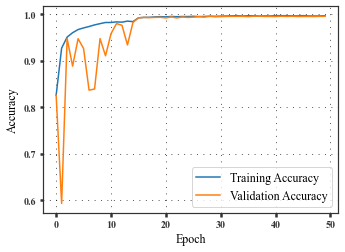

C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:296: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  y_pred = model.predict_generator(test_set,verbose=1)


313/313 [==============================] - 47s 148ms/step


C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])

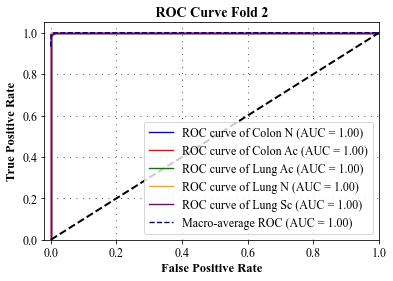

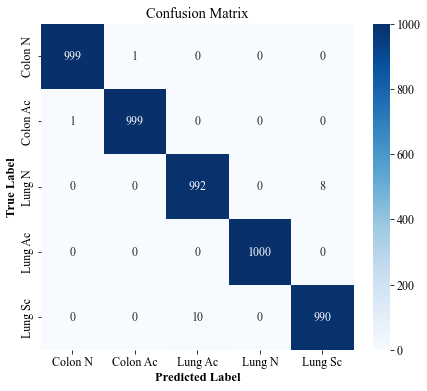

Fold 2
Accuracy: 0.9960
Precision (Macro): 0.9960
Recall (Macro): 0.9960
F1 Score (Macro): 0.9960
Kappa Score : 0.9950
AUC : 0.9999
Found 20000 images belonging to 5 classes.
Found 0 images belonging to 5 classes.
Found 5000 images belonging to 5 classes.
Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_18 (Conv2D)             (None, 224, 224, 8)  224         ['input_4[0][0]']                
                                                                                                  
 batch_normalization_27 (BatchN  (

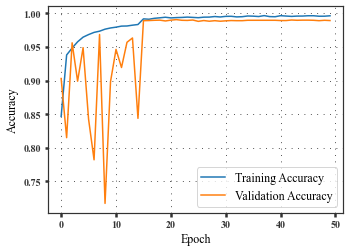

C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:296: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  y_pred = model.predict_generator(test_set,verbose=1)


313/313 [==============================] - 48s 152ms/step


C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])

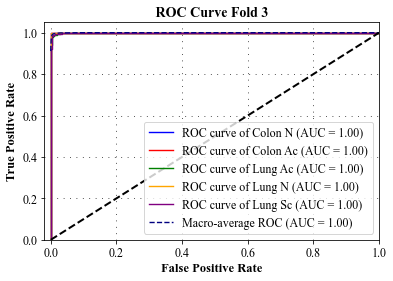

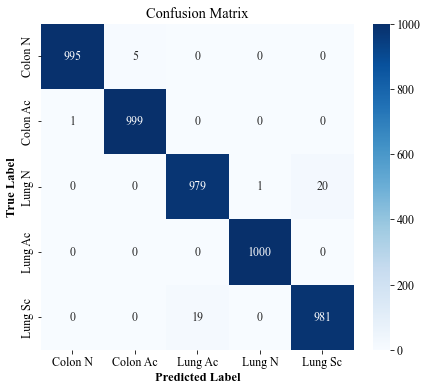

Fold 3
Accuracy: 0.9908
Precision (Macro): 0.9908
Recall (Macro): 0.9908
F1 Score (Macro): 0.9908
Kappa Score : 0.9885
AUC : 0.9998
Found 20000 images belonging to 5 classes.
Found 0 images belonging to 5 classes.
Found 5000 images belonging to 5 classes.
Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_24 (Conv2D)             (None, 224, 224, 8)  224         ['input_5[0][0]']                
                                                                                                  
 batch_normalization_36 (BatchN  (

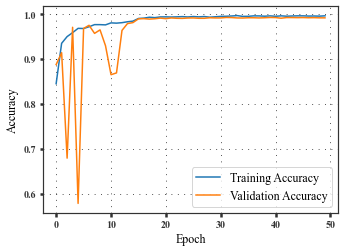

C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:296: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  y_pred = model.predict_generator(test_set,verbose=1)


313/313 [==============================] - 47s 148ms/step


C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])

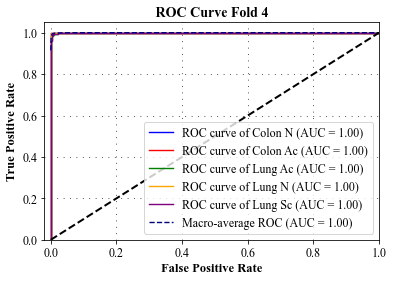

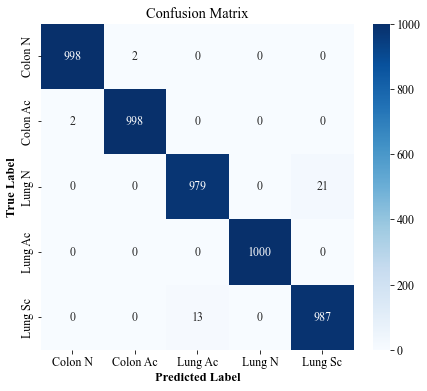

Fold 4
Accuracy: 0.9924
Precision (Macro): 0.9924
Recall (Macro): 0.9924
F1 Score (Macro): 0.9924
Kappa Score : 0.9905
AUC : 0.9998
Found 20000 images belonging to 5 classes.
Found 0 images belonging to 5 classes.
Found 5000 images belonging to 5 classes.
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_30 (Conv2D)             (None, 224, 224, 8)  224         ['input_6[0][0]']                
                                                                                                  
 batch_normalization_45 (BatchN  (

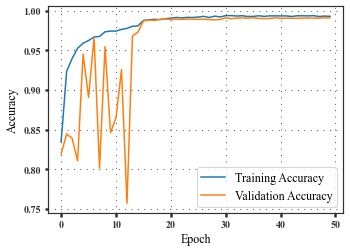

C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:296: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  y_pred = model.predict_generator(test_set,verbose=1)


313/313 [==============================] - 47s 150ms/step


C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:339: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])

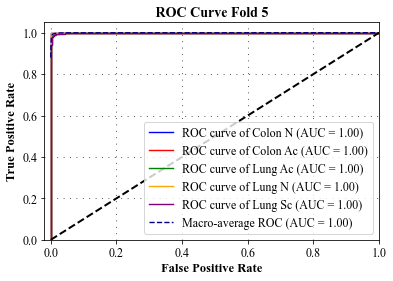

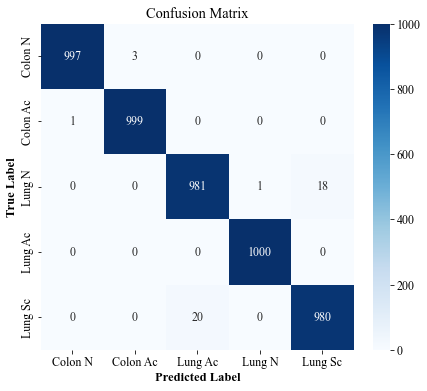

Fold 5
Accuracy: 0.9914
Precision (Macro): 0.9914
Recall (Macro): 0.9914
F1 Score (Macro): 0.9914
Kappa Score : 0.9892
AUC : 0.9998


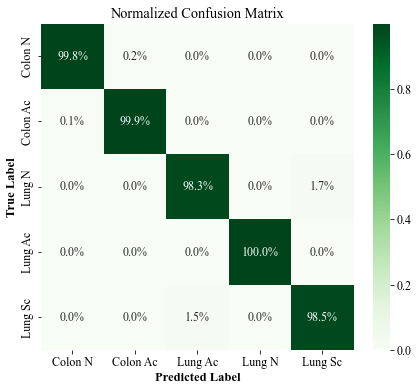

Average Accuracy: 0.99268
Standard Deviation of Accuracy: 0.0018048822676285615
Average Sensitivity: 0.99268
Standard Deviation of Sensitivity: 0.0018048822676286268
Average Precision: 0.99268361101824
Standard Deviation of Precision: 0.001805258516915662
Average F1 Score: 0.992681805498402
Standard Deviation of F1 Score: 0.001805068359584736
Average Kappa Score: 0.99085
Standard Deviation of Kappa Score: 0.00225610283453569
Average AUC Score: 0.99982078
Standard Deviation of AUC Score: 6.63474008533727e-05


C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:558: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:558: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:558: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it
C:\Users\Student\AppData\Local\Temp/ipykernel_2680/1405243783.py:558: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])

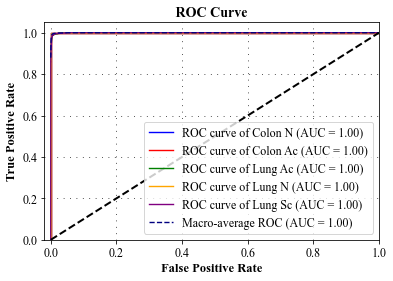

Data saved to M:/LC25000 journal/ROCdata/Final_5-fold_y_true_proba_all_custom3_Batch16_ECA attention-relu-Adam_5class)_5fold.pkl


In [5]:
from tensorflow.keras.applications import EfficientNetV2M, DenseNet121,MobileNetV2,VGG16,ResNet50
import os 
history_dense=[]
Accuracy=[]
Sensitivity=[]
Precision=[]
F1_Score=[]
kappa=[]
AUC=[]
y_true_proba_all = []
y_pred_proba_all = []

# Number of classes (replace with the number of classes in your dataset)
num_classes = 5  # Example with 6 classes (adjust as needed)

# Placeholder for the sum of confusion matrices across folds
cm_sum = np.zeros((num_classes, num_classes))

for k in range(1,6):
    
    train="train"+str(k)
    test="test"+str(k)
    tr="M:/LC25000/original/"
    ts="M:/LC25000/original/"
    
    train_dir = os.path.join(tr,train)
    test_dir = os.path.join(ts,test)
    #val_dir = "M:/Old Files/Bipul/LC/5 fold/"  


    #train_datagen = ImageDataGenerator( validation_split=0.125)
                                   #shear_range = 0.2,
                                   #zoom_range = 0.2,
                                   
    train_datagen = ImageDataGenerator(rescale = 1./255)

    test_datagen = ImageDataGenerator(rescale = 1./255)
    #Through flow_from_directory - we create an array of images that can be used for training. 
    training_set = train_datagen.flow_from_directory(
                                                     train_dir,
                                                     target_size = (224, 224),
                                                     batch_size = 16,
                                                     class_mode = 'categorical',
                                                     subset='training')
    validation_set = train_datagen.flow_from_directory(train_dir,
                                                     target_size = (224, 224),
                                                     batch_size = 16,
                                                     class_mode = 'categorical',
                                                     subset='validation',
                                                      shuffle=False)
    test_set = test_datagen.flow_from_directory(test_dir,
                                                target_size = (224, 224),
                                                batch_size = 16,
                                                class_mode = 'categorical',
                                                shuffle=False)

    

    import tensorflow as tf
    from tensorflow.keras import layers
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Input, DepthwiseConv2D, Conv2D, GlobalAveragePooling2D, Dense, BatchNormalization, Multiply, Reshape, Activation

    from tensorflow.keras import layers
    from tensorflow.keras.utils import get_custom_objects
    from keras import backend as K
    from tensorflow.keras import layers
    from tensorflow.keras.layers import Layer
    ### Note! You cannot use random python functions, activation function gets as an input tensorflow tensors and should return tensors. There are a lot of helper functions in keras backend.
   


    # Squeeze and Excitation (SE) Block
    def SEBlock(input_tensor, reduction_ratio=16):
        channel_axis = -1
        channel_dim = input_tensor.shape[channel_axis]

        se = GlobalAveragePooling2D()(input_tensor)
        se = Reshape((1, 1, channel_dim))(se)
        se = Dense(channel_dim // reduction_ratio, activation='relu')(se)
        se = Dense(channel_dim, activation='sigmoid')(se)

        return Multiply()([input_tensor, se])

    # Lightweight Attention Module
    def AttentionModule(input_tensor):
        attention = Conv2D(1, (1, 1), padding='same')(input_tensor)
        attention = Activation('sigmoid')(attention)

        return Multiply()([input_tensor, attention])

    # Build the Model
    def build_model(input_shape=(224, 224, 3)):
        input_tensor = Input(shape=input_shape)

        x = Conv2D(8, kernel_size=(3, 3), padding='same')(input_tensor)
        x = BatchNormalization()(x)
        #x = CombinedAReLUATanh()(x)  # Using the Combined Adaptive Activation here
        #x=TaLU(alpha=0.0, trainable=True)(x)
        x= Activation('relu')(x)
        # First Depthwise Separable Convolution Block
        x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', depth_multiplier=1)(x)
        x = BatchNormalization()(x)
        #x = CombinedAReLUATanh()(x)  # Using the Combined Adaptive Activation here
        #x=TaLU(alpha=0.0, trainable=True)(x)
        x= Activation('relu')(x)
        #x= MaxPool2D()(x)
        x = Conv2D(8, kernel_size=(1, 1), padding='same')(x)
        x = BatchNormalization()(x)
        #x = CombinedAReLUATanh()(x)  # Using the Combined Adaptive Activation here
        #x=TaLU(alpha=0.0, trainable=True)(x)
        x= Activation('relu')(x)
        x= MaxPool2D()(x)

        # Apply SE Block after the first convolutional block
       # x = SEBlock(x)
        x=eca(x)

        # Second Depthwise Separable Convolution Block
        x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', depth_multiplier=1)(x)
        x = BatchNormalization()(x)
        #x = CombinedAReLUATanh()(x)  # Using the Combined Adaptive Activation here
        #x=TaLU(alpha=0.0, trainable=True)(x)
        x= Activation('relu')(x)
        #x= MaxPool2D()(x)
        x = Conv2D(16, kernel_size=(1, 1), padding='same')(x)
        x = BatchNormalization()(x)
        #x = CombinedAReLUATanh()(x)  # Using the Combined Adaptive Activation here
        #x=TaLU(alpha=0.0, trainable=True)(x)
        x= Activation('relu')(x)
        x= MaxPool2D()(x)

        # Apply SE Block again
        #x = SEBlock(x)
        x=eca(x)

        
        # third Depthwise Separable Convolution Block
        x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', depth_multiplier=1)(x)
        x = BatchNormalization()(x)
        #x = CombinedAReLUATanh()(x)  # Using the Combined Adaptive Activation here
        #x=TaLU(alpha=0.0, trainable=True)(x)
        x= Activation('relu')(x)
        x= MaxPool2D()(x)
        x = Conv2D(32, kernel_size=(1, 1), padding='same')(x)
        x = BatchNormalization()(x)
        #x = CombinedAReLUATanh()(x)  # Using the Combined Adaptive Activation here
        #x=TaLU(alpha=0.0, trainable=True)(x)
        x= Activation('relu')(x)
        x= MaxPool2D()(x)

        # Apply SE Block again
        #x = SEBlock(x)
        x=eca(x)
        
        

        
         # 4th Depthwise Separable Convolution Block
        
        x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', depth_multiplier=1)(x)
        x = BatchNormalization()(x)
        #x = CombinedAReLUATanh()(x)  # Using the Combined Adaptive Activation here
        #x=TaLU(alpha=0.0, trainable=True)(x)
        x= Activation('relu')(x)
        x= MaxPool2D()(x)
        x = Conv2D(32, kernel_size=(1, 1), padding='same')(x)
        x = BatchNormalization()(x)
        #x = CombinedAReLUATanh()(x)  # Using the Combined Adaptive Activation here
        #x=TaLU(alpha=0.0, trainable=True)(x)
        x= Activation('relu')(x)
        x= MaxPool2D()(x)

    

        # Apply SE Block again
        #x = SEBlock(x)
        
        # Apply Attention Module
        x = AttentionModule(x)

        # Global Average Pooling
        #x = GlobalAveragePooling2D()(x)
        x=Flatten()(x)

        # Fully Connected Layer
        #x = Dense(256, activation='relu')(x)
        #x = Dense(32, activation='relu')(x)

        # Output Layer (for a 3-class classification task)
        output = Dense(5, activation='softmax')(x)

        # Create the model
        model = Model(inputs=input_tensor, outputs=output)

        return model

    # Instantiate the model
    model = build_model()

    # Print model summary
    model.summary()
    

    from tensorflow.keras import optimizers
    from tensorflow.keras.callbacks import ReduceLROnPlateau
    from tensorflow.keras.losses import CategoricalCrossentropy
    from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ModelCheckpoint

    # Load your model here (the code from the previous responses)

    # initiate Adadelta optimizer with a learning rate of 0.1
    adadelta = optimizers.Adam(learning_rate=0.001)

    def lr_scheduler(epoch):
        return 0.001 * (0.1 ** (epoch // 15))
    #reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=10, min_lr=1e-7)

    reduce_lr = LearningRateScheduler(lr_scheduler)
    
    import os
    model_path = f"C:/Users/Student/LC25000/Final_5-fold_Adam_5class_custom3_Batch16_model_ECAattention_relu_Fold{k}.h5"
   

    monitor_callbacks = [
        
        ModelCheckpoint(model_path, monitor='val_accuracy', mode='max', save_best_only=True)
     
    ]
    epoch=50
    
    # Use SparseCategoricalCrossentropy as the loss function
    model.compile(loss=CategoricalCrossentropy(), optimizer=adadelta, metrics=['accuracy'])

    # Assuming you have your training and validation data generators defined as 'training_set' and 'validation_set'
    history = model.fit(
        training_set,
        validation_data=test_set,
        epochs=epoch,
        callbacks= [monitor_callbacks,reduce_lr]
    )
    plt.figure(edgecolor='black',figsize=(5.3,3.8)).clf()
    ax=plt.axes()
    ax.set_facecolor('white')

   
        
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Training Accuracy', 'Validation Accuracy'], loc='lower right',facecolor='white')
    #plt.legend(fontsize="11",loc="lower right",facecolor='white')
    #plt.legend()
    plt.xticks(size='10',weight='bold',color='0.2')
    plt.yticks(size='10',weight='bold',color='0.2')
    ax.tick_params(axis='both', width=2.5,color='0.2')

    for axis in ['bottom','top','left','right']:
        ax.spines[axis].set_color('0.2')
        ax.spines[axis].set_linewidth('1.2')



    ax.grid(color='black',linestyle=(0, (1,7)))
    #plt.figure()

    #plt.plot(epochs, loss, 'bo', label='Training loss')
    #plt.plot(epochs, val_loss, 'b', label='Validation loss')
    #plt.title('Training and validation accuracy and loss')
    #plt.ylim(0.8, 1)

    plt.show()
    
    history_dense.append(history)

    ##confusion matrix for binary classification

    ##confusion matrix for binary classification
   
    from tensorflow.keras.models import load_model

    model = load_model(model_path)



    from sklearn.metrics import confusion_matrix
    import tensorflow as tf
    import numpy as np 
    from sklearn.metrics import confusion_matrix,classification_report
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_auc_score

    y_pred = model.predict_generator(test_set,verbose=1)
    # for future use
    y_pred_proba_all.append(y_pred)
    #y_pred=np.argmax((y_pred), axis=1)
    y_true=test_set.classes
     # for future use 
    y_true_proba_all.append(y_true)

    #####################ROC############
    import numpy as np
    from sklearn.metrics import roc_curve, auc
    import numpy as np
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    import matplotlib.pyplot as plt
    from scipy import interp

    # Assuming you have the following variables:
    # y_true_proba_all: true labels in the form [0, 3, 1, 4, 4, 2]
    # y_pred_proba_all: predicted probabilities, shape should be (n_samples, n_classes)

    # Number of classes
    n_classes = len(np.unique(y_true))
    
    # Custom class labels
    class_labels = ['Colon N', 'Colon Ac',  'Lung Ac','Lung N', 'Lung Sc']

    # Binarize the output labels for one-vs-rest classification
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # To calculate the macro average
    all_fpr = np.unique(np.concatenate([roc_curve(y_true_bin[:, i], y_pred[:, i])[0] for i in range(n_classes)]))

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it

    mean_tpr /= n_classes  # Average the TPR

    # Compute AUC for the macro-average ROC curve
    macro_roc_auc = auc(all_fpr, mean_tpr)

    # Plot all ROC curves including macro-average
    plt.figure()
    ax=plt.axes()
    ax.set_facecolor('white')
    ax.grid(color='black',linestyle=(0, (1,7)))

    colors = ['blue', 'red', 'green', 'orange', 'purple']  # Add more colors if you have more classes
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=1.4, label='ROC curve of {0} (AUC = {1:0.2f})'.format(class_labels[i], roc_auc[i]))

    # Plot the macro-average ROC curve
    plt.plot(all_fpr, mean_tpr, color='navy', linestyle='--', lw=1.4, label='Macro-average ROC (AUC = {0:0.2f})'.format(macro_roc_auc))

    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['font.size'] = 12  # Default font size for everything
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.02, 1.0])
    plt.ylim([0.0, 1.05])
    # Set Times New Roman font, bold, black for labels, title, and legend
    font_options = {'family': 'Times New Roman', 'size': 12.5, 'weight': 'bold', 'color': 'black'}
    legend_options = {'family': 'Times New Roman', 'size': 12}

    plt.xlabel('False Positive Rate', fontdict=font_options)
    plt.ylabel('True Positive Rate', fontdict=font_options)
    plt.title(f' ROC Curve Fold {k} ', fontdict={'family': 'Times New Roman', 'size': 14, 'weight': 'bold', 'color': 'black'})
    plt.legend(loc="lower right", prop=legend_options)

    plt.show()

    #################################C M ########################################

    
    y_pred=np.argmax((y_pred), axis=1)
    
    
    
    
    
    # Create a confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Normalize the confusion matrix
    cm_normalized = cm / np.sum(cm, axis=1, keepdims=True)
    
    
    # Accumulate the confusion matrices
    cm_sum += cm

    # Plot the confusion matrix
    plt.figure(figsize=(7, 6))
    # Create labels with both counts and percentages
    #labels = np.array([["{0}\n{1:.1%}".format(count, percentage) for count, percentage in zip(row, cm_normalized_row)]
                       #for row, cm_normalized_row in zip(cm, cm_normalized)])

    #sns.heatmap(cm_normalized, annot=True, fmt='d', cmap='Blues', xticklabels=['Colon N', 'Colon Ac', 'Lung N','Lung Ac','Lung Sc'], yticklabels=['Colon N', 'Colon Ac', 'Lung N','Lung Ac','Lung Sc'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Colon N', 'Colon Ac', 'Lung Ac','Lung N','Lung Sc'], yticklabels=['Colon N', 'Colon Ac', 'Lung N','Lung Ac','Lung Sc'])

    plt.xlabel('Predicted Label', fontdict=font_options)
    plt.ylabel('True Label', fontdict=font_options)
    plt.title('Confusion Matrix')
    plt.show()
    
    #print(classification_report( y_true,y_pred))



    # Calculate accuracy
    accuracy = np.trace(cm) / np.sum(cm)

    # Calculate precision, recall, and F1 score for each class
    precision = np.diag(cm) / np.sum(cm, axis=0)
    recall = np.diag(cm) / np.sum(cm, axis=1)
    

    # Average metrics for multi-class case (e.g., macro average)
    precision_macro = np.mean(precision)
    recall_macro = np.mean(recall)
    #f1_score_macro = np.mean(f1_score)
    f1_score_macro = 2 * (precision_macro * recall_macro) / (precision_macro + recall_macro)
    
    
    # Step 2: Calculate the Observed Agreement (Po)
    total_instances = np.sum(cm)
    correct_predictions = np.trace(cm)  # Sum of diagonal elements (correct predictions)
    Po = correct_predictions / total_instances

    # Step 3: Calculate the Expected Agreement (Pe)
    row_totals = np.sum(cm, axis=1)  # Sum of rows (actual labels)
    column_totals = np.sum(cm, axis=0)  # Sum of columns (predicted labels)

    # Calculate expected agreement
    Pe = np.sum((row_totals * column_totals) / (total_instances ** 2))

    # Step 4: Calculate the Kappa score
    kappa_score = (Po - Pe) / (1 - Pe)

    print("Fold",k)
    # Print the results
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision (Macro): {precision_macro:.4f}')
    print(f'Recall (Macro): {recall_macro:.4f}')
    print(f'F1 Score (Macro): {f1_score_macro:.4f}')
    print(f'Kappa Score : {kappa_score:.4f}')
    print(f'AUC : {macro_roc_auc:.4f}')
    
    
    kappa.append(kappa_score)
    
    Accuracy.append(accuracy)
    Sensitivity.append(recall_macro)
    Precision.append(precision_macro)
    F1_Score.append(f1_score_macro)
    AUC.append(macro_roc_auc)
    
y_pred_proba_all=np.concatenate(y_pred_proba_all)
y_true_proba_all=np.concatenate(y_true_proba_all)    

# Average the confusion matrix over the number of folds
cm_avg = cm_sum / 5  # Divide by 5 (number of folds)

# Normalize the averaged confusion matrix (row-wise normalization)
cm_avg_normalized = cm_avg.astype('float') / cm_avg.sum(axis=1, keepdims=True)

# Plot the confusion matrix
plt.figure(figsize=(7, 6))
# Create labels with both counts and percentages
#labels = np.array([["{0}\n{1:.1%}".format(count, percentage) for count, percentage in zip(row, cm_normalized_row)]
                   #for row, cm_normalized_row in zip(cm, cm_normalized)])

#sns.heatmap(cm_normalized, annot=True, fmt='d', cmap='Blues', xticklabels=['Colon N', 'Colon Ac', 'Lung N','Lung Ac','Lung Sc'], yticklabels=['Colon N', 'Colon Ac', 'Lung N','Lung Ac','Lung Sc'])

sns.heatmap(cm_avg_normalized, annot=True, fmt='0.1%', cmap='Greens', xticklabels=['Colon N', 'Colon Ac' ,'Lung Ac','Lung N','Lung Sc'], yticklabels=['Colon N', 'Colon Ac', 'Lung N','Lung Ac','Lung Sc'])

plt.xlabel('Predicted Label', fontdict=font_options)
plt.ylabel('True Label', fontdict=font_options)
plt.title('Normalized Confusion Matrix')


# Set your custom save location (for example, D:/plots/)
save_path = "M:/LC25000 journal/CM/Final_5-fold-custom3_Batch16_ECA attention-relu-Adam_5class)).png"

# Create the directory if it does not exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Save the plot with high resolution (dpi=300)
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show() 

# Calculate and print the average and standard deviation for each metric
print('Average Accuracy:', np.average(Accuracy))
print('Standard Deviation of Accuracy:', np.std(Accuracy))

print('Average Sensitivity:', np.average(Sensitivity))
print('Standard Deviation of Sensitivity:', np.std(Sensitivity))

print('Average Precision:', np.average(Precision))
print('Standard Deviation of Precision:', np.std(Precision))

print('Average F1 Score:', np.average(F1_Score))
print('Standard Deviation of F1 Score:', np.std(F1_Score))





print('Average Kappa Score:', np.average(kappa))
print('Standard Deviation of Kappa Score:', np.std(kappa))

print('Average AUC Score:', np.average(AUC))
print('Standard Deviation of AUC Score:', np.std(AUC))



############################################5-fold roc#####################


import numpy as np
from sklearn.metrics import roc_curve, auc
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from scipy import interp

# Assuming you have the following variables:
# y_true_proba_all: true labels in the form [0, 3, 1, 4, 4, 2]
# y_pred_proba_all: predicted probabilities, shape should be (n_samples, n_classes)

# Number of classes
n_classes = len(np.unique(y_true_proba_all))

# Custom class labels
class_labels = ['Colon N', 'Colon Ac',  'Lung Ac','Lung N', 'Lung Sc']

# Binarize the output labels for one-vs-rest classification
y_true_bin = label_binarize(y_true_proba_all, classes=np.arange(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# To calculate the macro average
all_fpr = np.unique(np.concatenate([roc_curve(y_true_bin[:, i], y_pred_proba_all[:, i])[0] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba_all[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])  # Interpolate each TPR and sum it

mean_tpr /= n_classes  # Average the TPR

# Compute AUC for the macro-average ROC curve
macro_roc_auc = auc(all_fpr, mean_tpr)

# Plot all ROC curves including macro-average
plt.figure()
ax=plt.axes()
ax.set_facecolor('white')
ax.grid(color='black',linestyle=(0, (1,7))) 

colors = ['blue', 'red', 'green', 'orange', 'purple']  # Add more colors if you have more classes
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=1.4, label='ROC curve of {0} (AUC = {1:0.2f})'.format(class_labels[i], roc_auc[i]))

# Plot the macro-average ROC curve
plt.plot(all_fpr, mean_tpr, color='navy', linestyle='--', lw=1.4, label='Macro-average ROC (AUC = {0:0.2f})'.format(macro_roc_auc))

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14  # Default font size for everything
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
# Set Times New Roman font, bold, black for labels, title, and legend
font_options = {'family': 'Times New Roman', 'size': 12.5, 'weight': 'bold', 'color': 'black'}
legend_options = {'family': 'Times New Roman', 'size': 12}

plt.xlabel('False Positive Rate', fontdict=font_options)
plt.ylabel('True Positive Rate', fontdict=font_options)
plt.title(f' ROC Curve ', fontdict={'family': 'Times New Roman', 'size': 14, 'weight': 'bold', 'color': 'black'})
plt.legend(loc="lower right", prop=legend_options)

# Set your custom save location (for example, D:/plots/)
save_path = "M:/LC25000 journal/ROC/Final_5-fold-custom3_Batch16_ECA attention-relu-Adam_5class)).png.png"

# Create the directory if it does not exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Save the plot with high resolution (dpi=300)
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

import pickle
# Specify the file path where you want to save the data
file_path = "M:/LC25000 journal/ROCdata/Final_5-fold_y_pred_proba_all_custom3_Batch16_ECA attention-relu-Adam_5class))_5fold.pkl"

# Save the data to a file using pickle
with open(file_path, "wb") as file:
    pickle.dump(y_pred_proba_all, file)
    
    
# Specify the file path where you want to save the data
file_path = "M:/LC25000 journal/ROCdata/Final_5-fold_y_true_proba_all_custom3_Batch16_ECA attention-relu-Adam_5class)_5fold.pkl"

# Save the data to a file using pickle
with open(file_path, "wb") as file:
    pickle.dump(y_true_proba_all, file)

print(f"Data saved to {file_path}")


# Load the data from the file
#import pickle
#with open('y_pred_proba_all_densenet121_5fold.pkl', "rb") as file:
    #activation_average = pickle.load(file)

In [ ]:
32